In [20]:
!pip install yfinance

In [21]:
import yfinance as yf
data = yf.download("NKE", period="10y", interval="1d", auto_adjust=True, progress=False)
data

Price,Close,High,Low,Open,Volume
Ticker,NKE,NKE,NKE,NKE,NKE
Date,,,,,
2016-06-24,45.826344,46.497313,45.469074,45.625924,18481200
2016-06-27,45.216366,45.765342,44.859097,45.312219,15265700
2016-06-28,46.262024,46.357877,44.937513,45.347067,20837800
2016-06-29,48.039661,48.048374,46.087749,47.490686,36084800
2016-06-30,48.100655,48.301074,47.577819,48.179080,17350500
...,...,...,...,...,...
2026-06-17,44.189999,45.849998,44.160000,44.900002,20859700
2026-06-18,45.200001,45.709999,44.240002,44.410000,32320300


In [22]:
data.shape

(2513, 5)

In [23]:
data.to_csv("stock_data.csv")

In [24]:
data

Price,Close,High,Low,Open,Volume
Ticker,NKE,NKE,NKE,NKE,NKE
Date,,,,,
2016-06-24,45.826344,46.497313,45.469074,45.625924,18481200
2016-06-27,45.216366,45.765342,44.859097,45.312219,15265700
2016-06-28,46.262024,46.357877,44.937513,45.347067,20837800
2016-06-29,48.039661,48.048374,46.087749,47.490686,36084800
2016-06-30,48.100655,48.301074,47.577819,48.179080,17350500
...,...,...,...,...,...
2026-06-17,44.189999,45.849998,44.160000,44.900002,20859700
2026-06-18,45.200001,45.709999,44.240002,44.410000,32320300


In [25]:
# from google.colab import files
# files.download("stock_data.csv")

In [26]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2513 entries, 2016-06-24 to 2026-06-24
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   (Close, NKE)   2513 non-null   float64
 1   (High, NKE)    2513 non-null   float64
 2   (Low, NKE)     2513 non-null   float64
 3   (Open, NKE)    2513 non-null   float64
 4   (Volume, NKE)  2513 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 117.8 KB


In [27]:
data.describe().round()

Price,Close,High,Low,Open,Volume
Ticker,NKE,NKE,NKE,NKE,NKE
count,2513.0,2513.0,2513.0,2513.0,2513.0
mean,84.0,85.0,83.0,84.0,9526238.0
std,29.0,29.0,29.0,29.0,7732575.0
min,42.0,42.0,41.0,42.0,1821900.0
25%,61.0,62.0,61.0,61.0,5712400.0
50%,78.0,79.0,77.0,78.0,7527200.0
75%,102.0,104.0,101.0,102.0,10705200.0
max,164.0,165.0,162.0,163.0,129967000.0


In [28]:
data.duplicated().sum()

np.int64(0)

In [29]:
data.isnull().sum()

,,0
Price,Ticker,
Close,NKE,0
High,NKE,0
Low,NKE,0
Open,NKE,0
Volume,NKE,0


In [30]:
data.columns = data.columns.droplevel(1)
data.head()

Price,Close,High,Low,Open,Volume
Date,,,,,
2016-06-24,45.826344,46.497313,45.469074,45.625924,18481200
2016-06-27,45.216366,45.765342,44.859097,45.312219,15265700
2016-06-28,46.262024,46.357877,44.937513,45.347067,20837800
2016-06-29,48.039661,48.048374,46.087749,47.490686,36084800
2016-06-30,48.100655,48.301074,47.577819,48.179080,17350500


In [31]:
data.columns.name = None
data.index.name = "Date"
display(data.head())

,Close,High,Low,Open,Volume
Date,,,,,
2016-06-24,45.826344,46.497313,45.469074,45.625924,18481200
2016-06-27,45.216366,45.765342,44.859097,45.312219,15265700
2016-06-28,46.262024,46.357877,44.937513,45.347067,20837800
2016-06-29,48.039661,48.048374,46.087749,47.490686,36084800
2016-06-30,48.100655,48.301074,47.577819,48.179080,17350500


In [32]:
display(data.head())

,Close,High,Low,Open,Volume
Date,,,,,
2016-06-24,45.826344,46.497313,45.469074,45.625924,18481200
2016-06-27,45.216366,45.765342,44.859097,45.312219,15265700
2016-06-28,46.262024,46.357877,44.937513,45.347067,20837800
2016-06-29,48.039661,48.048374,46.087749,47.490686,36084800
2016-06-30,48.100655,48.301074,47.577819,48.179080,17350500


In [35]:
data = data.reset_index()
data = data[['Date', 'Close', 'High', 'Low', 'Open', 'Volume']]

In [36]:
display(data.head())

,Date,Close,High,Low,Open,Volume
0,2016-06-24,45.826344,46.497313,45.469074,45.625924,18481200
1,2016-06-27,45.216366,45.765342,44.859097,45.312219,15265700
2,2016-06-28,46.262024,46.357877,44.937513,45.347067,20837800
3,2016-06-29,48.039661,48.048374,46.087749,47.490686,36084800
4,2016-06-30,48.100655,48.301074,47.577819,48.179080,17350500


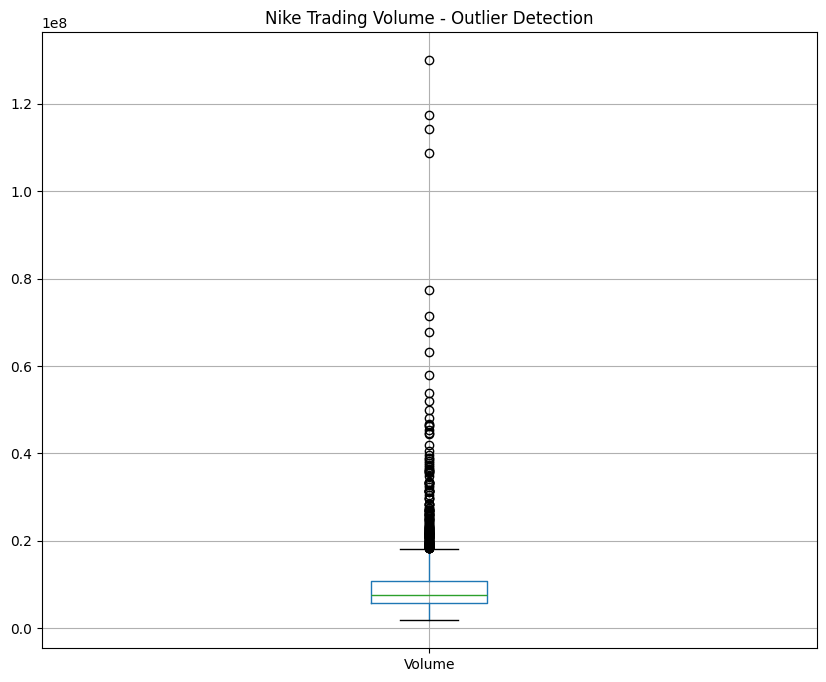

In [38]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 8))
data.boxplot(column=['Volume'])
plt.title("Nike Trading Volume - Outlier Detection")
plt.show()

In [40]:
Q1 = data['Volume'].quantile(0.25)
Q3 = data['Volume'].quantile(0.75)
IQR = Q3 - Q1
upper_limit = Q3 + 1.5 * IQR
data['Volume'] = data['Volume'].clip(upper=upper_limit)

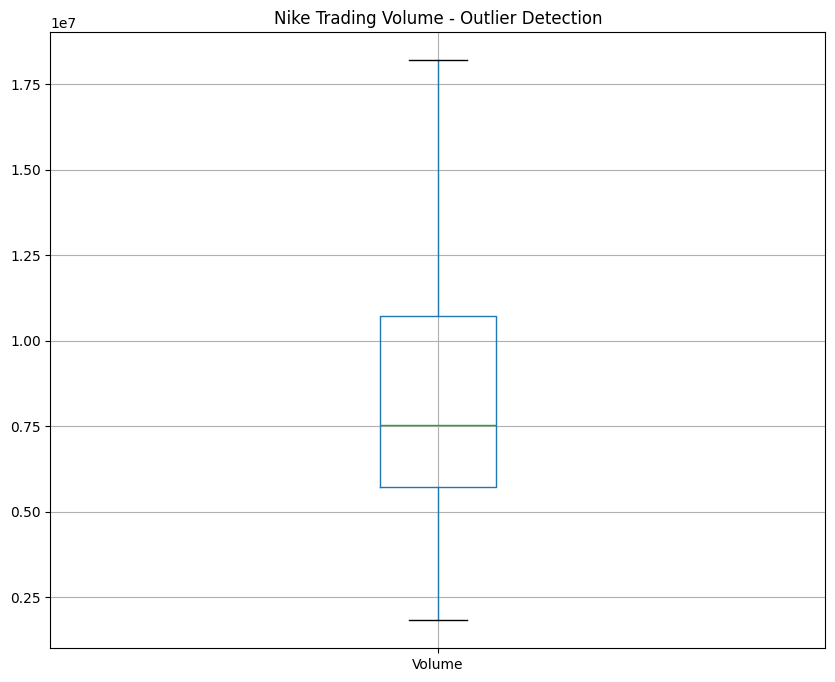

In [42]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 8))
data.boxplot(column=['Volume'])
plt.title("Nike Trading Volume - Outlier Detection")
plt.show()

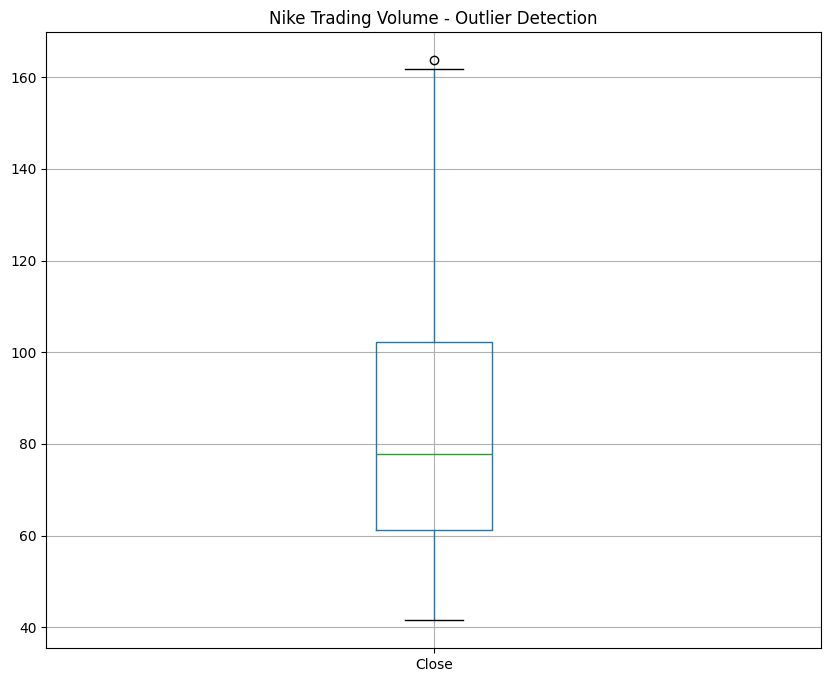

In [43]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 8))
data.boxplot(column=['Close'])
plt.title("Nike Trading Volume - Outlier Detection")
plt.show()